# Exploración de Datos Sísmicos del Ecuador

**Proyecto 0.3 | Regresión Lineal desde Cero**  
Portafolio: De Matemático a Data Scientist

---

**Fuente de datos:** USGS Earthquake Catalog — API pública `fdsnws/event/1/query`
(sismos de Ecuador, magnitud ≥ 2, período 2010–2025)  
**Dimensiones:** 1187 filas × 22 columnas  
**Objetivo:** Exploración enfocada del dataset sísmico para identificar las variables
más relevantes como predictoras de `depth` (profundidad en km). Este notebook
no es un EDA exhaustivo — es el paso previo a la implementación de regresión
lineal en el Notebook 02. Nuestra pregunta central es: ¿se observa en los datos la
geometría lineal de la zona de Wadati-Benioff (subducción de la placa de Nazca)?

In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset original (no modificar este archivo)
df = pd.read_csv("../data/raw/sismos_ecuador_usgs_2010_2025.csv")

print(f"Dataset cargado con éxito: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset cargado con éxito: 1187 filas × 22 columnas


## 1. Inspección inicial del dataset

Antes de analizar, se examina la estructura general del dataset: tipos de dato,
conteo de nulos por columna y valores únicos de las columnas categóricas clave
(`type`, `status`, `magType`).

In [2]:
# Primeras filas: ¿cómo lucen los datos crudos?
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-19T21:59:54.472Z,-0.7716,-77.9623,10.000,5.1,mww,72.0,43.0,0.429,1.03,...,2026-03-07T04:45:37.040Z,"22 km NW of Archidona, Ecuador",earthquake,5.06,1.789,0.098,10.0,reviewed,us,us
1,2025-12-16T00:30:40.757Z,-1.5529,-77.7537,181.434,4.1,mb,40.0,63.0,0.277,0.65,...,2026-03-10T22:18:43.040Z,"28 km NE of Palora, Ecuador",earthquake,8.87,4.766,0.105,25.0,reviewed,us,us
2,2025-12-14T20:23:42.032Z,-1.7675,-78.0415,155.618,4.5,mb,73.0,62.0,0.273,0.84,...,2026-03-10T22:18:41.040Z,"11 km SW of Palora, Ecuador",earthquake,7.48,4.152,0.045,144.0,reviewed,us,us
3,2025-12-13T09:40:52.633Z,-1.7801,-79.0621,10.000,4.0,mwr,55.0,91.0,0.636,0.90,...,2026-03-10T22:18:48.040Z,"8 km SSW of San Miguel, Ecuador",earthquake,3.53,1.833,0.086,13.0,reviewed,us,us
4,2025-11-17T23:13:51.062Z,-1.3210,-77.8568,177.305,4.2,mb,54.0,49.0,0.240,0.58,...,2026-02-10T15:55:13.040Z,"24 km NE of Puyo, Ecuador",earthquake,6.10,3.637,0.100,28.0,reviewed,us,us


In [3]:
# Tipos de dato y conteo de no-nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1187 entries, 0 to 1186
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             1187 non-null   str    
 1   latitude         1187 non-null   float64
 2   longitude        1187 non-null   float64
 3   depth            1187 non-null   float64
 4   mag              1187 non-null   float64
 5   magType          1187 non-null   str    
 6   nst              477 non-null    float64
 7   gap              1166 non-null   float64
 8   dmin             1011 non-null   float64
 9   rms              1177 non-null   float64
 10  net              1187 non-null   str    
 11  id               1187 non-null   str    
 12  updated          1187 non-null   str    
 13  place            1187 non-null   str    
 14  type             1187 non-null   str    
 15  horizontalError  966 non-null    float64
 16  depthError       1135 non-null   float64
 17  magError         1012 non

In [4]:
# Columnas categóricas clave: verificar valores únicos
for col in ["type", "status", "magType"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- type ---
type
earthquake    1187
Name: count, dtype: int64

--- status ---
status
reviewed    1187
Name: count, dtype: int64

--- magType ---
magType
mb     988
mww    101
ml      43
mwr     32
mwc     11
mwb      9
md       3
Name: count, dtype: int64


## 2. Inventario de columnas

### 2.1 Contexto del dataset y diccionario de variables

El dataset proviene del catálogo público del USGS (*United States Geological Survey*).
Cada fila representa un sismo registrado en el territorio ecuatoriano entre 2010 y 2025,
con magnitud ≥ 2. Las 22 columnas se agrupan en tres categorías naturales:
coordenadas del evento, propiedades del sismo y metadatos de la medición.

**Diccionario de variables:**

| Columna | Descripción |
|---------|-------------|
| `time` | Fecha y hora UTC del evento |
| `latitude` | Latitud del epicentro (grados, negativo = hemisferio sur) |
| `longitude` | Longitud del epicentro (grados, negativo = oeste de Greenwich) |
| `depth` | Profundidad del hipocentro en kilómetros bajo la superficie |
| `mag` | Magnitud del sismo (escala indicada en `magType`) |
| `magType` | Escala de magnitud utilizada: mb (body-wave), mww (moment tensor), ml (local), mwr (regional moment), mwc (centroid), mwb (body-wave moment), md (duración) |
| `nst` | Número de estaciones sísmicas que registraron el evento |
| `gap` | Brecha azimutal: mayor ángulo (en grados) sin estaciones alrededor del epicentro. Valores altos indican cobertura pobre |
| `dmin` | Distancia (en grados) a la estación más cercana |
| `rms` | Residual cuadrático medio del ajuste de localización (segundos). Mide la precisión del cálculo del hipocentro |
| `net` | Red sísmica que contribuyó la información (ej: "us" = USGS) |
| `id` | Identificador único del evento en el catálogo USGS |
| `updated` | Fecha y hora de la última actualización del registro |
| `place` | Descripción textual de la ubicación (ej: "22 km NW of Archidona, Ecuador") |
| `type` | Tipo de evento. En este dataset es constante: "earthquake" |
| `horizontalError` | Error estimado de la localización horizontal (km) |
| `depthError` | Error estimado de la profundidad (km) |
| `magError` | Error estimado de la magnitud |
| `magNst` | Número de estaciones usadas para calcular la magnitud |
| `status` | Estado de revisión. En este dataset es constante: "reviewed" |
| `locationSource` | Fuente que calculó la localización |
| `magSource` | Fuente que calculó la magnitud |

### 2.2 ¿Por qué elegir `depth` como la variable objetivo?

En Ecuador, la placa oceánica de Nazca se hunde (subduce) bajo la placa Sudamericana
en dirección aproximada oeste→este. Los sismos ocurren a lo largo de esta superficie
de contacto, conocida como **zona de Wadati-Benioff**. La geometría implica una
relación aproximadamente lineal:

- Sismos **cerca de la costa** (longitud más negativa) → la placa apenas comienza
  a hundirse → **profundidad baja**
- Sismos **tierra adentro** (longitud menos negativa) → la placa ya se hundió
  considerablemente → **profundidad alta**

Esta relación entre posición geográfica y profundidad es lo que una regresión lineal
puede capturar. La alternativa natural — usar `mag` como target — no tiene
sustento físico, pues la magnitud de un sismo no depende de su ubicación.

| # | Columna | Tipo | No-nulos | Clasificación | Justificación |
|---|---------|------|----------|---------------|---------------|
| 0 | `time` | str | 1187 | Metadato | Timestamp del evento. No tiene relación física con la profundidad |
| 1 | `latitude` | float64 | 1187 | **Feature candidata** | Posición N-S del epicentro. Relevante para la geometría de subducción |
| 2 | `longitude` | float64 | 1187 | **Feature candidata** | Posición E-W del epicentro. Variable principal: a mayor distancia de la fosa → mayor profundidad |
| 3 | `depth` | float64 | 1187 | **Variable objetivo** | Profundidad en km. Es lo que se busca predecir |
| 4 | `mag` | float64 | 1187 | **Feature candidata (con reserva)** | Magnitud del sismo. Sin nulos, pero mezcla 7 escalas distintas (ver `magType`). Evaluar si aporta poder predictivo |
| 5 | `magType` | str | 1187 | Metadato | Escala de magnitud usada (mb, mww, ml...). Útil para interpretar `mag`, no como feature numérica directa |
| 6 | `nst` | float64 | 477 | Descartable | Número de estaciones. Solo 40.2% de completitud — demasiados nulos |
| 7 | `gap` | float64 | 1166 | Metadato | Brecha azimutal entre estaciones. Mide calidad de la localización, no propiedad del sismo |
| 8 | `dmin` | float64 | 1011 | Metadato | Distancia mínima a la estación más cercana. Propiedad de la red sísmica, no del sismo |
| 9 | `rms` | float64 | 1177 | Metadato | Residual del ajuste de localización. Mide precisión del cálculo, no propiedad física |
| 10 | `net` | str | 1187 | Descartable | Red sísmica que reportó. Identificador administrativo |
| 11 | `id` | str | 1187 | Descartable | Identificador único del evento |
| 12 | `updated` | str | 1187 | Descartable | Fecha de última actualización del registro |
| 13 | `place` | str | 1187 | Metadato | Descripción textual de ubicación. Redundante con `latitude`/`longitude` |
| 14 | `type` | str | 1187 | Descartable | Constante: "earthquake" en todas las filas |
| 15 | `horizontalError` | float64 | 966 | Metadato | Error de localización horizontal. Calidad del dato, no propiedad del sismo |
| 16 | `depthError` | float64 | 1135 | Metadato | Error estimado de la profundidad. Interesante pero no predictivo |
| 17 | `magError` | float64 | 1012 | Metadato | Error de la magnitud. Calidad del dato |
| 18 | `magNst` | float64 | 1126 | Metadato | Estaciones usadas para calcular magnitud. Propiedad de la red |
| 19 | `status` | str | 1187 | Descartable | Constante: "reviewed" en todas las filas |
| 20 | `locationSource` | str | 1187 | Descartable | Fuente de la localización. Administrativo |
| 21 | `magSource` | str | 1187 | Descartable | Fuente de la magnitud. Administrativo |

**Resumen:** De 22 columnas, 3 son features candidatas (`latitude`, `longitude`, `mag`),
1 es la variable objetivo (`depth`), y las 18 restantes son metadatos o descartables.
La decisión final sobre `mag` se toma después de analizar su correlación con `depth`
y el efecto de la mezcla de escalas.  
La distinción entre **metadato** y **descartable** es sutil pero importante. Un metadato como depthError (el error estimado al calcular la profundidad) tiene información real, pero describe la precisión de la medición, no una propiedad física del sismo. Incluirlo en el modelo mezclaría señal física con ruido instrumental. Una columna descartable como type (que dice "earthquake" en todas las filas) ni siquiera tiene eso, es literalmente una constante, y una constante no aporta varianza.

## 3. Variable objetivo: `depth`

El primer paso en cualquier problema de regresión es conocer la distribución de
la variable que se busca predecir. Los estadísticos descriptivos revelan la escala
y dispersión; el histograma revela si la distribución es unimodal, bimodal o tiene
estructura interna. En este caso, se anticipa una distribución bimodal: sismos
corticales superficiales (0–30 km) y sismos de subducción profundos (100–200 km).

In [5]:
# Estadísticos descriptivos del target
df["depth"].describe()

count    1187.000000
mean       62.149020
std        54.929455
min         0.000000
25%        10.000000
50%        42.170000
75%       101.915000
max       239.400000
Name: depth, dtype: float64

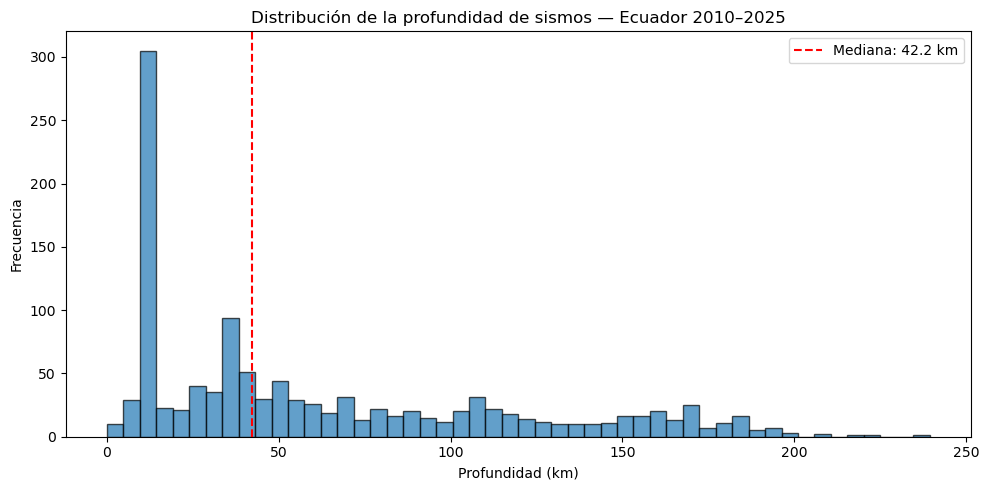

In [6]:
# Distribución de depth — ¿se observa la bimodalidad?
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["depth"], bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Profundidad (km)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la profundidad de sismos — Ecuador 2010–2025")
ax.axvline(df["depth"].median(), color="red", linestyle="--", label=f'Mediana: {df["depth"].median():.1f} km')
ax.legend()
plt.tight_layout()
fig.savefig("../reports/figures/distribucion_depth.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Interpretación de la variable objetivo

La distribución de `depth` muestra dos poblaciones claramente distinguibles:

- **Sismos corticales (0–30 km):** concentran la mayor frecuencia. Son sismos
  superficiales que ocurren dentro de la corteza terrestre, asociados a fallas
  locales en la Sierra y el Oriente ecuatoriano.
- **Sismos de subducción (~100–200 km):** distribución más dispersa. Son sismos
  profundos que ocurren a lo largo de la zona de Wadati-Benioff, donde la placa
  de Nazca se hunde bajo la placa Sudamericana.

**Implicaciones para el modelo:**

| Estadístico | Valor |
|-------------|-------|
| Media | 62.15 km |
| Mediana | 42.17 km |
| Desviación estándar | 54.93 km |
| Mínimo | 0.00 km |
| Máximo | 239.40 km |

La diferencia media − mediana (~20 km) confirma la asimetría positiva.
Una regresión lineal ajustada sobre **todos** los datos será un compromiso
entre ambas poblaciones. Esta limitación se analizará en el Notebook 03 —
donde se explorará si un modelo entrenado solo sobre sismos de subducción
captura mejor la geometría de la zona de Wadati-Benioff.

## 5. Análisis de nulos

Ya sabemos que `latitude`, `longitude` y `depth` no tienen nulos (lo mostró df.info()). Pero `mag` tampoco tenía nulos, y las otras columnas numéricas sí. Queremos cuantificar los nulos solo en las columnas que podrían ser relevantes, para no perder tiempo analizando columnas ya descartadas.
El resultado esperado es una tabla con el porcentaje de nulos de cada columna, ordenada de mayor a menor. Se limita a las features candidatas y la variable objetivo — no tiene sentido revisar nulos de id o net.

In [7]:
# Nulos en columnas relevantes para el modelo
cols_relevantes = ["latitude", "longitude", "depth", "mag"]

nulos = (
    df[cols_relevantes]
    .isnull()
    .sum()
    .to_frame(name="nulos")
)
nulos["porcentaje"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos = nulos.sort_values("porcentaje", ascending=False)

print("Nulos en features candidatas y variable objetivo:\n")
print(nulos.to_string())

Nulos en features candidatas y variable objetivo:

           nulos  porcentaje
latitude       0         0.0
longitude      0         0.0
depth          0         0.0
mag            0         0.0


## 6. Visualización geográfica

Se representan los sismos en el plano longitud–latitud, coloreados por profundidad
y escalados por magnitud. Aunque no es un mapa cartográfico, la escala de Ecuador
hace que la distorsión sea mínima. Si la zona de Wadati-Benioff existe en los datos,
se espera un gradiente de color de oeste (costa, profundidad baja) a este (interior,
profundidad alta).

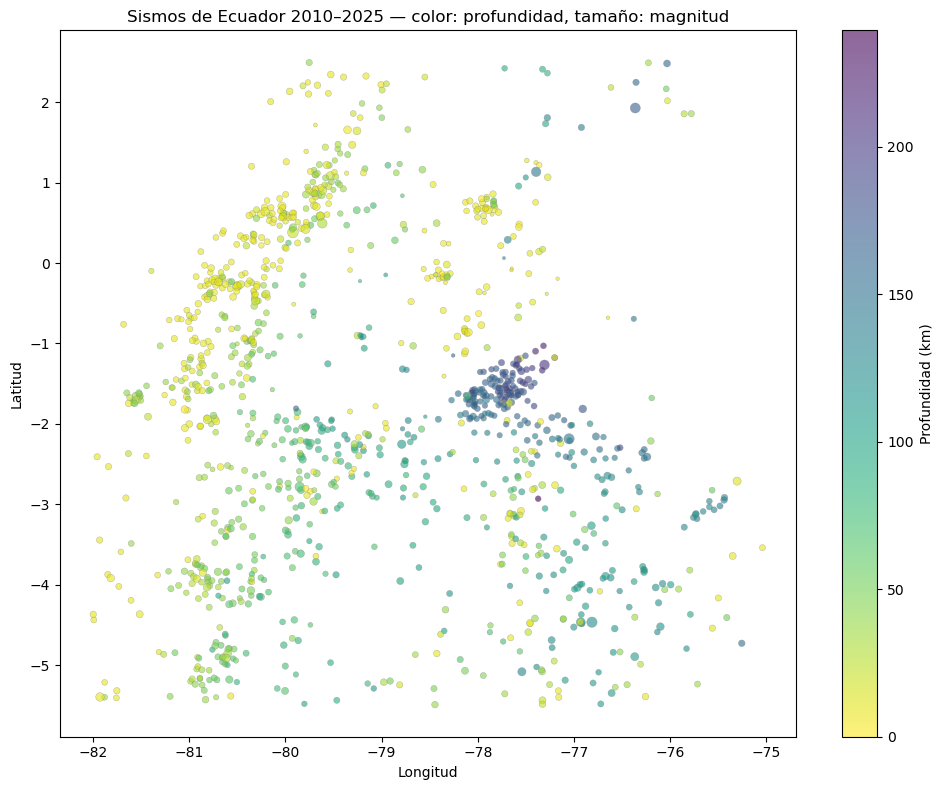

In [8]:
# Distribución geográfica de sismos, coloreada por profundidad
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["depth"],
    cmap="viridis_r",       # Colores claros = superficial, oscuros = profundo
    s=df["mag"] ** 2,       # Tamaño proporcional a magnitud (cuadrado para que se note)
    alpha=0.6,
    edgecolors="gray",
    linewidths=0.3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Profundidad (km)")

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Sismos de Ecuador 2010–2025 — color: profundidad, tamaño: magnitud")
plt.tight_layout()
fig.savefig("../reports/figures/scatter_geografico_sismos.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Corte transversal de la zona de Wadati-Benioff

Esta es la visualización central del proyecto. En lugar de ver los sismos desde arriba
(mapa geográfico), se observan "de perfil": longitud en el eje horizontal y profundidad
en el eje vertical **invertido** (mayor profundidad hacia abajo, como en la realidad).
Si la zona de Wadati-Benioff existe en los datos, los puntos deben trazar una pendiente
descendente de oeste a este — la placa de Nazca hundiéndose bajo la Sudamericana.

El color representa la magnitud del sismo, no la profundidad (que ya está codificada
en la posición vertical). Esto permite observar si los sismos más grandes se concentran
en alguna zona particular de la geometría de subducción.

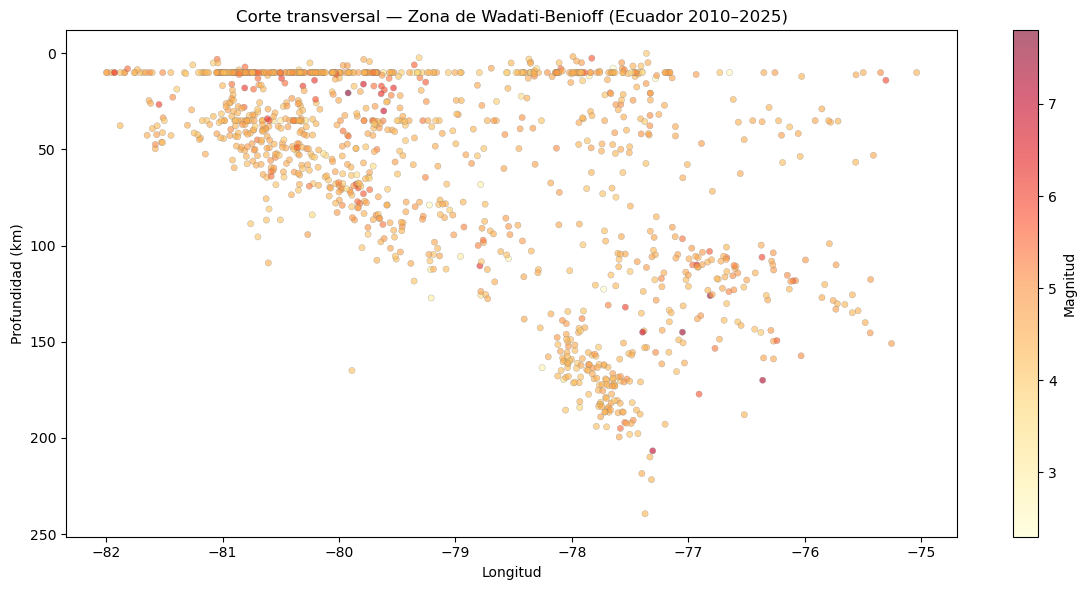

In [9]:
# Corte transversal: longitud vs profundidad (eje y invertido)
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    df["longitude"],
    df["depth"],
    c=df["mag"],
    cmap="YlOrRd",          # Amarillo = magnitud baja, rojo = magnitud alta
    s=20,
    alpha=0.6,
    edgecolors="gray",
    linewidths=0.3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Magnitud")

ax.invert_yaxis()           # Profundidad crece hacia abajo
ax.set_xlabel("Longitud")
ax.set_ylabel("Profundidad (km)")
ax.set_title("Corte transversal — Zona de Wadati-Benioff (Ecuador 2010–2025)")
plt.tight_layout()
fig.savefig("../reports/figures/corte_transversal_wadati_benioff.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Interpretación conjunta

Las dos visualizaciones anteriores muestran el mismo fenómeno desde perspectivas
complementarias:

- **Vista superior** (longitud vs latitud): los sismos superficiales (colores claros)
  se concentran a lo largo de la costa y la Sierra, mientras que los sismos profundos
  (colores oscuros) se agrupan hacia el interior, especialmente alrededor de
  longitudes −78 a −77.
- **Corte transversal** (longitud vs profundidad): se observa una pendiente descendente
  de oeste a este que traza la geometría de la zona de Wadati-Benioff — la placa de
  Nazca hundiéndose bajo la placa Sudamericana. Los sismos pasan de ~10 km de
  profundidad en la costa a ~200 km en el interior.

**Observaciones relevantes para el modelo:**

1. La relación entre `longitude` y `depth` es aproximadamente lineal en los sismos de
   subducción, lo que justifica el uso de regresión lineal para predecir `depth`
   a partir de la posición geográfica.
2. Existe una banda horizontal de sismos corticales (profundidad ~0–10 km) en todas
   las longitudes. Estos sismos **no siguen** la pendiente de subducción — desde la
   perspectiva del modelo, son ruido.
4. La magnitud (color en el corte transversal) no muestra un patrón espacial claro —
   hay sismos fuertes y débiles en todas las profundidades, lo que sugiere que `mag`
   podría no ser un buen predictor de `depth`.

## 7. Análisis de correlación

Antes de calcular correlaciones entre las features candidatas y `depth`, se debe
elegir qué coeficiente de correlación usar. La elección no es trivial — la
distribución bimodal de `depth` puede distorsionar algunos coeficientes.

### 7.1 Elección del coeficiente de correlación

| Coeficiente | Qué mide | Supuestos | Riesgo en este dataset |
|-------------|----------|-----------|------------------------|
| **Pearson** ($r$) | Relación lineal entre dos variables continuas | Asume que ambas variables se distribuyen de forma aproximadamente normal, o al menos que la relación es lineal y homocedástica | La bimodalidad de `depth` viola el supuesto de normalidad. Pearson puede reportar una correlación alta simplemente porque hay dos clusters separados, no porque la relación sea lineal dentro de cada grupo |
| **Spearman** ($\rho_s$) | Relación monótona (no necesariamente lineal) basada en los rangos de los datos | No asume distribución normal ni relación lineal — solo que si una variable crece, la otra también (o decrece) | Más robusto ante la bimodalidad, pero no distingue entre una relación lineal y una curva monótona cualquiera |
| **Kendall** ($\tau$) | Concordancia entre pares: proporción de pares de observaciones que están en el mismo orden en ambas variables | Similar a Spearman pero más robusto con muestras pequeñas o con empates | Computacionalmente más lento ($O(n^2)$) y aporta poca información adicional sobre Spearman con $n = 1187$ |

**Decisión:** Se calcula **Pearson y Spearman** en paralelo. Si ambos coinciden en
las features más correlacionadas con `depth`, la conclusión es robusta. Si difieren,
la discrepancia indica que la bimodalidad está afectando a Pearson y se prioriza
Spearman. Se descarta Kendall porque con 1187 filas Spearman ya es suficientemente
robusto y más interpretable.

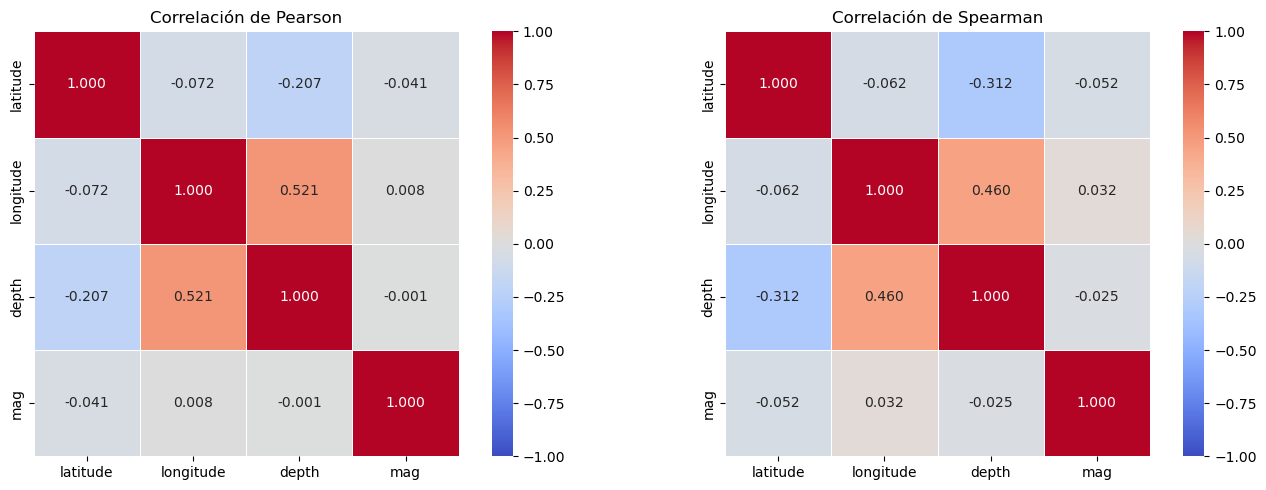

In [10]:
# Features candidatas + variable objetivo
cols_modelo = ["latitude", "longitude", "depth", "mag"]

# Correlación de Pearson
corr_pearson = df[cols_modelo].corr(method="pearson")

# Correlación de Spearman
corr_spearman = df[cols_modelo].corr(method="spearman")

# Visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Pearson", "Spearman"]
):
    sns.heatmap(
        corr,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f"Correlación de {titulo}")

plt.tight_layout()
fig.savefig("../reports/figures/heatmap_correlacion_pearson_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Top correlaciones con depth (excluyendo depth consigo misma)
print("Correlaciones con depth:\n")
print("Pearson:")
print(corr_pearson["depth"].drop("depth").sort_values(key=abs, ascending=False).to_string())
print("\nSpearman:")
print(corr_spearman["depth"].drop("depth").sort_values(key=abs, ascending=False).to_string())

Correlaciones con depth:

Pearson:
longitude    0.520747
latitude    -0.206773
mag         -0.000646

Spearman:
longitude    0.460400
latitude    -0.312238
mag         -0.024530


### 7.2 Interpretación de correlaciones

Ambos métodos producen el mismo orden de correlación con `depth`:
`longitude` en primer lugar, `latitude` en segundo y `mag` sin correlación relevante.

| Feature | Pearson | Spearman | Interpretación |
|---------|---------|----------|----------------|
| `longitude` | 0.521 | 0.460 | Correlación positiva moderada. Consistente con la geometría de subducción: a mayor longitud (más al este) mayor profundidad. Pearson ligeramente mayor que Spearman, lo cual sugiere que la bimodalidad de `depth` infla levemente la correlación lineal |
| `latitude` | −0.207 | −0.312 | Correlación negativa débil a moderada. Spearman la detecta con más fuerza, lo que indica una relación monótona no estrictamente lineal. Tiene sentido geográfico: la geometría de subducción varía con la latitud |
| `mag` | −0.001 | −0.025 | Correlación esencialmente nula. Confirma que la magnitud de un sismo no depende de su profundidad — no es un predictor útil de `depth` |

**Multicolinealidad entre features:** la correlación entre `longitude` y `latitude`
es baja (Pearson: −0.072, Spearman: −0.062), por lo que ambas pueden incluirse
en el modelo sin riesgo de multicolinealidad.

**Conclusión preliminar:** `longitude` es la feature principal. `latitude` aporta
información adicional. `mag` se descarta como predictor de `depth`.

### 7.3 Relación individual de cada feature con `depth`

Los coeficientes de correlación resumen la relación en un solo número, pero no
muestran la forma de esa relación. Un scatter plot revela si es lineal, curva,
si tiene clusters o valores atípicos. Se grafica cada feature candidata contra
`depth` para inspeccionar visualmente lo que los coeficientes no pueden capturar.

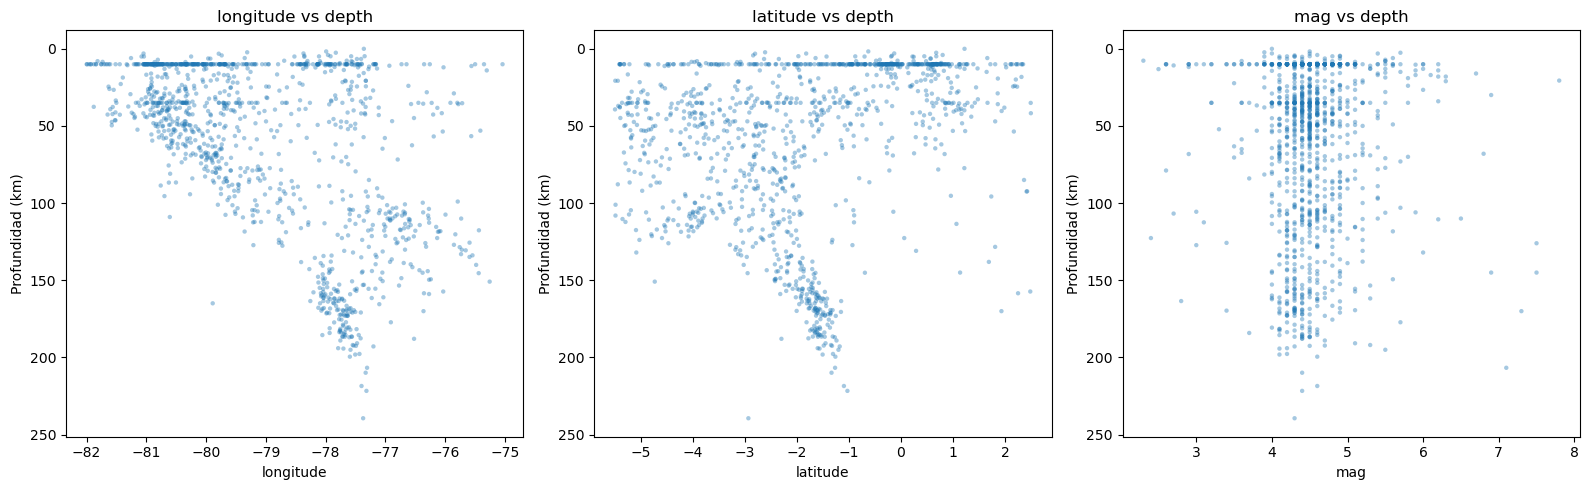

In [12]:
# Scatter individual de cada feature candidata vs depth
features = ["longitude", "latitude", "mag"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df["depth"], alpha=0.4, s=10, edgecolors="none")
    ax.set_xlabel(feat)
    ax.set_ylabel("Profundidad (km)")
    ax.set_title(f"{feat} vs depth")
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig("../reports/figures/scatter_features_vs_depth.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Selección de features

A partir del análisis de correlación y los scatter plots, se define la lista
de features que se usarán en el Notebook 02 para entrenar el modelo de
regresión lineal.

### 8.1 Tabla de decisión

| Feature | Correlación con `depth` (Pearson / Spearman) | Evidencia visual | Decisión | Justificación |
|---------|----------------------------------------------|------------------|----------|---------------|
| `longitude` | 0.521 / 0.460 | Pendiente descendente clara (Wadati-Benioff) con banda de ruido cortical | **Incluir — feature principal** | Es la variable con mayor correlación y con sustento físico directo: la distancia a la fosa oceánica determina la profundidad de la placa que subduce |
| `latitude` | −0.207 / −0.312 | Los sismos profundos se concentran entre latitud −3 y 0, pero la relación no es lineal | **Incluir — feature secundaria** | Aporta información adicional sobre la geometría tridimensional de la subducción. La correlación es moderada y la baja multicolinealidad con `longitude` (−0.072) permite incluirla sin riesgo |
| `mag` | −0.001 / −0.025 | Nube sin estructura | **Excluir** | Correlación esencialmente nula. La magnitud de un sismo no depende de la profundidad a la que ocurre. Incluirla añadiría ruido sin mejorar la predicción |

### 8.2 Nota sobre `magType`

La columna `mag` mezcla 7 escalas de magnitud distintas:

| Escala | Cantidad | Porcentaje |
|--------|----------|------------|
| mb | 988 | 83.2% |
| mww | 101 | 8.5% |
| ml | 43 | 3.6% |
| mwr | 32 | 2.7% |
| mwc | 11 | 0.9% |
| mwb | 9 | 0.8% |
| md | 3 | 0.3% |

Aunque `mag` se descarta como feature, vale documentar esta mezcla, los valores
de magnitud no son estrictamente comparables entre escalas. Si en un proyecto
futuro se quisiera usar `mag` como feature, habría que filtrar por una sola escala
(mb, que concentra el 83.2%) o aplicar conversiones entre escalas.

**Lista definitiva de features para el Notebook 02:**
- `longitude` (feature principal)
- `latitude` (feature secundaria)
- Variable objetivo: `depth`

## 9. Preparación del dataset para modelado

Se filtran las columnas seleccionadas, se eliminan filas con valores nulos
(si las hubiera) y se guarda el resultado en `data/processed/` como archivo CSV.
Este archivo es el que consume el Notebook 02.

In [13]:
# Filtrar solo las columnas seleccionadas
cols_finales = ["longitude", "latitude", "depth"]
df_clean = df[cols_finales].copy()

# Eliminar filas con nulos (verificación — se espera que no haya ninguna)
filas_antes = len(df_clean)
df_clean = df_clean.dropna() #Va a dar cero, pero para la reproducibilidad
filas_despues = len(df_clean)
filas_eliminadas = filas_antes - filas_despues

print(f"Filas antes:      {filas_antes}")
print(f"Filas después:    {filas_despues}")
print(f"Filas eliminadas: {filas_eliminadas}")

# Guardar dataset procesado
ruta_salida = "../data/processed/sismos_clean.csv"
df_clean.to_csv(ruta_salida, index=False)

print(f"\nDataset guardado en: {ruta_salida}")
print(f"Dimensiones finales: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")

Filas antes:      1187
Filas después:    1187
Filas eliminadas: 0

Dataset guardado en: ../data/processed/sismos_clean.csv
Dimensiones finales: 1187 filas × 3 columnas


## 10. Resumen

### Datos originales vs datos finales

| Aspecto | Dataset original | Dataset procesado |
|---------|-----------------|-------------------|
| Archivo | `data/raw/sismos_ecuador_usgs_2010_2025.csv` | `data/processed/sismos_clean.csv` |
| Filas | 1187 | 1187 (sin pérdida) |
| Columnas | 22 | 3 |
| Columnas conservadas | — | `longitude`, `latitude`, `depth` |
| Nulos | Presentes en 7 columnas (metadatos) | 0 |

### Features seleccionadas

| Feature | Rol | Correlación con `depth` (Pearson / Spearman) |
|---------|-----|----------------------------------------------|
| `longitude` | Feature principal | 0.521 / 0.460 |
| `latitude` | Feature secundaria | −0.207 / −0.312 |
| `depth` | Variable objetivo | — |

Se descartó `mag` por correlación nula con `depth` (−0.001 / −0.025)
y por la mezcla de 7 escalas de magnitud distintas.

### Hallazgos clave

1. La distribución de `depth` es bimodal: sismos corticales (0–30 km) y sismos
   de subducción (100–200 km). Esto implica que una regresión lineal sobre todos
   los datos será un compromiso entre dos poblaciones distintas.
2. El corte transversal longitud–profundidad confirma visualmente la geometría
   de la zona de Wadati-Benioff: la placa de Nazca se hunde hacia el este con
   una pendiente aproximadamente lineal.
3. `longitude` y `latitude` tienen baja correlación entre sí (−0.072), por lo que
   pueden incluirse juntas en el modelo sin riesgo de multicolinealidad.

### Siguiente paso

El Notebook 02 toma el dataset procesado (`sismos_clean.csv`) e implementa
regresión lineal desde cero con NumPy: solución analítica, gradient descent
y verificación contra Scikit-learn.